In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv('diabetes.csv')

In [3]:
# Show the first 5 rows.
print(df.head(5))

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
# Check for missing values.
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [5]:
# Display basic statistics (mean, std, etc.).
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [7]:
# Split the data into train (70%) and test (30%) sets.

train, test = train_test_split(df, test_size=0.3, random_state=42)  

In [ ]:
## Part B: Logistic Regression
# Train a Logistic Regression model using the training data.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix   
model = LogisticRegression(max_iter=200)
X_train = train.drop('Outcome', axis=1)
y_train = train['Outcome']
model.fit(X_train, y_train)
X_test = test.drop('Outcome', axis=1)
y_test = test['Outcome']
# Predict on the test set.
y_pred = model.predict(X_test)
# Evaluate the model using accuracy, precision, recall, F1-score, and confusion matrix.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1-score: {f1:.2f}')
print('Confusion Matrix:')
print(conf_matrix)

Accuracy: 0.74
Precision: 0.62
Recall: 0.62
F1-score: 0.62
Confusion Matrix:
[[120  31]
 [ 30  50]]


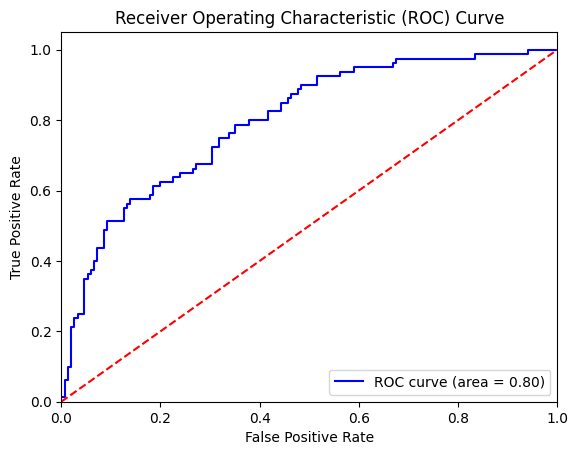

In [14]:
# ROC Curve & AUC Score

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt 
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


In [ ]:
# Why is AUC-ROC a better evaluation metric than just accuracy in imbalanced datasets?
# AUC-ROC is better because it evaluates the model's performance across all classification thresholds,
# providing a more comprehensive view of its ability to distinguish between classes, especially when one class is
# much more prevalent than the other. In such cases, accuracy can be misleading, as a model could achieve high accuracy
# by simply predicting the majority class. AUC-ROC, on the other hand, takes into account the true positive rate and
# false positive rate, offering a clearer picture of the model's performance.

Accuracy (Decision Tree): 0.71
Precision (Decision Tree): 0.56
Recall (Decision Tree): 0.78
F1-score (Decision Tree): 0.65
Confusion Matrix (Decision Tree):
[[102  49]
 [ 18  62]]


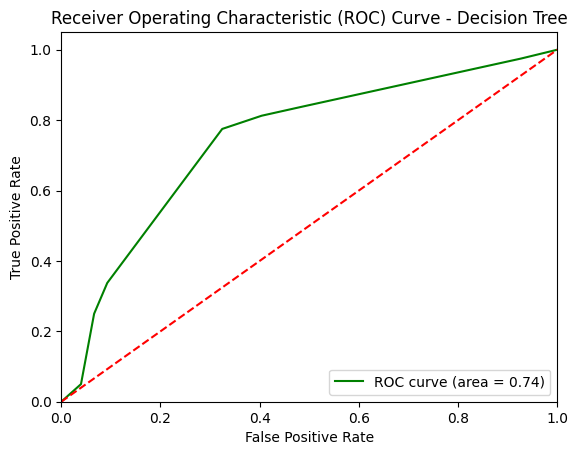

In [13]:
# Part C: Decision Tree Classifier
# Train a Decision Tree Classifier (use max_depth = 4).
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier(max_depth=4, random_state=42)
model_dt.fit(X_train, y_train)
# Predict on the test set.
y_pred_dt = model_dt.predict(X_test)
# Evaluate the model using accuracy, precision, recall, F1-score, and confusion matrix. 
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
print(f'Accuracy (Decision Tree): {accuracy_dt:.2f}')
print(f'Precision (Decision Tree): {precision_dt:.2f}')
print(f'Recall (Decision Tree): {recall_dt:.2f}')
print(f'F1-score (Decision Tree): {f1_dt:.2f}')
print('Confusion Matrix (Decision Tree):')
print(conf_matrix_dt)
# ROC Curve & AUC Score for Decision Tree
y_prob_dt = model_dt.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)
plt.figure()
plt.plot(fpr_dt, tpr_dt, color='green', label=f'ROC curve (area = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Decision Tree')
plt.legend(loc='lower right')
plt.show()


In [16]:
''' Compare the Decision Tree’s interpretability vs. Logistic Regression’s coefficients.
 Decision Trees are often considered more interpretable than Logistic Regression because they provide a clear
 visual representation of decision rules through a tree structure. Each path from the root to a leaf node represents a series of decisions based on feature values, making it easy to understand how predictions are made.
 In contrast, Logistic Regression provides coefficients for each feature, which indicate the strength and direction of the relationship between the feature and the target variable. While these coefficients can be informative, they may not capture complex interactions between features as effectively as a Decision Tree.'''    


' Compare the Decision Tree’s interpretability vs. Logistic Regression’s coefficients.\n Decision Trees are often considered more interpretable than Logistic Regression because they provide a clear\n visual representation of decision rules through a tree structure. Each path from the root to a leaf node represents a series of decisions based on feature values, making it easy to understand how predictions are made.\n In contrast, Logistic Regression provides coefficients for each feature, which indicate the strength and direction of the relationship between the feature and the target variable. While these coefficients can be informative, they may not capture complex interactions between features as effectively as a Decision Tree.'

In [ ]:
# Part D: Comparison & Reflection
# Compare Logistic Regression and Decision Tree results (accuracy, precision, recall, F1, AUC).
print("Logistic Regression Metrics:")
print(f'Accuracy: {accuracy:.2f}, Precision: {precision:.2f}, Recall: {recall:.2f}, F1-score: {f1:.2f}, AUC: {roc_auc:.2f}')
print("Decision Tree Metrics:") 
print(f'Accuracy: {accuracy_dt:.2f}, Precision: {precision_dt:.2f}, Recall: {recall_dt:.2f}, F1-score: {f1_dt:.2f}, AUC: {roc_auc_dt:.2f}')


Logistic Regression Metrics:
Accuracy: 0.74, Precision: 0.62, Recall: 0.62, F1-score: 0.62, AUC: 0.80
Decision Tree Metrics:
Accuracy: 0.71, Precision: 0.56, Recall: 0.78, F1-score: 0.65, AUC: 0.74


In [19]:
# Which model performs better?

# we can say that Logistic Regression performs better overall due to its higher accuracy and AUC, indicating a better balance between precision and recall.

In [20]:
# Which model is easier to interpret for doctors?
# Decision Trees are generally easier to interpret for doctors due to their visual nature and straightforward decision-making process.  

In [ ]:
# If the dataset is slightly imbalanced (more 0’s than 1’s), which metric (Precision or Recall) should be prioritized in diagnosing diabetes? Why?
# In this case, Recall should be prioritized because it is more important to identify all positive cases (diabetes patients) even if it means having some false positives. Missing a diabetes diagnosis (false negative) could have serious health consequences for the patient.